## PyMCによるマルコフ連鎖モンテカルロ法による分布推定

In [2]:
import numpy as np
import scipy.stats as st
import scipy.linalg as la
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
%matplotlib inline
import japanize_matplotlib

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


回帰モデルのベイズ分析(自然共役事前分布)

In [43]:
# 回帰モデルからの人工データの生成
n = 50
np.random.seed(99)

# 誤差項 u
u = st.norm.rvs(scale=0.7, size=n)

# 説明変数
x = st.uniform.rvs(loc=-np.sqrt(3.0), scale=2.0*np.sqrt(3.0), size=n)

# 被説明変数
y = 1.0 + 2.0 * x + u

In [44]:
# 回帰モデルの係数と誤差項の事前分布
b0 = np.zeros(2) # 係数
A0 = 0.2 * np.eye(2) # 精度行列
nu0 = 5.0 # 自由度
lam0 = 7.0 # 尺度
h0 = np.sqrt(np.diag(lam0 / nu0 * la.inv(A0)))
sd0 = np.sqrt(np.diag(la.inv(A0)))

+ 事前分布の設定
+ 尤度の設定
+ 事後分布からのモンテカルロ標本の生成
+ 事後統計量の計算
+ 事後分布の作図

In [45]:
# 事前分布と尤度の設定
regression_conjugate = pm.Model()
with regression_conjugate:
    # 分散の事前分布
    sigma2 = pm.InverseGamma('sigma2', alpha=0.5*nu0, beta=0.5*lam0)
    sigma = pm.math.sqrt(sigma2)


    # 回帰係数の事前分布
    a = pm.Normal('a', mu=b0[0], sigma=sigma*sd0[0]) # 定数項
    b = pm.Normal('b', mu=b0[1], sigma=sigma*sd0[1]) # 説明変数x_1

    # 回帰モデルの条件付き期待値
    y_hat = a + b * x

    # 尤度
    likelihood = pm.Normal('y', mu=y_hat, sigma=sigma, observed=y)


# 事後分布からのサンプリング
n_draws = 5000
n_chains = 4
n_tune = 1000
with regression_conjugate:
    trace = pm.sample(draws=n_draws, chains=n_chains, tune=n_tune, random_seed=1234)

print(pm.summary(trace))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma2, a, b]


/home/inoue/miniconda3/envs/Py312Env/lib/python3.12/site-packages/rich/live.py:231: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 3 seconds.


         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
a       1.000  0.108   0.797    1.204      0.001    0.000   28532.0   15912.0   
b       2.003  0.111   1.798    2.217      0.001    0.000   25367.0   15513.0   
sigma2  0.588  0.116   0.390    0.804      0.001    0.001   25477.0   15879.0   

        r_hat  
a         1.0  
b         1.0  
sigma2    1.0  


In [46]:
# バーンイン
trace = trace.sel(draw=slice(200,None)) # 200以前を切り捨て. 各系列の先頭200を使わない.
print(trace)

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data


In [48]:
print(pm.summary(trace)) # バーンイン後のサマリー

         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
a       1.000  0.108   0.797    1.204      0.001    0.000   27220.0   15261.0   
b       2.004  0.111   1.798    2.216      0.001    0.000   25281.0   15003.0   
sigma2  0.588  0.116   0.389    0.804      0.001    0.001   24493.0   15289.0   

        r_hat  
a         1.0  
b         1.0  
sigma2    1.0  


In [49]:
print(trace.posterior)

<xarray.Dataset> Size: 499kB
Dimensions:  (chain: 4, draw: 4800)
Coordinates:
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 38kB 200 201 202 203 204 ... 4995 4996 4997 4998 4999
Data variables:
    a        (chain, draw) float64 154kB 1.04 0.9673 0.9011 ... 0.9138 1.102
    b        (chain, draw) float64 154kB 1.972 2.098 2.218 ... 2.204 2.071 2.0
    sigma2   (chain, draw) float64 154kB 0.5214 0.5342 0.5458 ... 0.7186 0.4203
Attributes:
    created_at:                 2025-02-01T10:26:01.978691+00:00
    arviz_version:              0.20.0
    inference_library:          pymc
    inference_library_version:  5.20.0
    sampling_time:              2.6110498905181885
    tuning_steps:               1000


In [50]:
print(trace.sample_stats)

<xarray.Dataset> Size: 2MB
Dimensions:                (chain: 4, draw: 4800)
Coordinates:
  * chain                  (chain) int64 32B 0 1 2 3
  * draw                   (draw) int64 38kB 200 201 202 203 ... 4997 4998 4999
Data variables: (12/17)
    acceptance_rate        (chain, draw) float64 154kB 0.8857 0.6959 ... 0.9571
    lp                     (chain, draw) float64 154kB -57.97 -58.26 ... -59.51
    perf_counter_diff      (chain, draw) float64 154kB 0.0003089 ... 0.0001589
    perf_counter_start     (chain, draw) float64 154kB 6.839e+03 ... 6.841e+03
    step_size              (chain, draw) float64 154kB 0.9713 0.9713 ... 0.9577
    tree_depth             (chain, draw) int64 154kB 2 2 2 2 2 2 ... 2 2 2 2 2 2
    ...                     ...
    diverging              (chain, draw) bool 19kB False False ... False False
    index_in_trajectory    (chain, draw) int64 154kB 2 2 -1 1 -1 ... -2 -2 -1 2
    largest_eigval         (chain, draw) float64 154kB nan nan nan ... nan nan
    

In [51]:
print(trace.observed_data)

<xarray.Dataset> Size: 800B
Dimensions:  (y_dim_0: 50)
Coordinates:
  * y_dim_0  (y_dim_0) int64 400B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
Data variables:
    y        (y_dim_0) float64 400B 4.073 -0.9147 -0.1001 ... -0.7814 -1.756
Attributes:
    created_at:                 2025-02-01T10:26:02.007649+00:00
    arviz_version:              0.20.0
    inference_library:          pymc
    inference_library_version:  5.20.0


In [52]:
trace.posterior['a']

<xarray.DataArray 'a' (chain: 4, draw: 4800)> Size: 154kB
array([[1.04039846, 0.96727964, 0.90109089, ..., 1.01689884, 1.00670818,
        0.99573089],
       [1.03491396, 0.83439852, 0.83439852, ..., 1.13449925, 0.98317981,
        1.0508314 ],
       [0.98482034, 0.93318679, 1.08945095, ..., 1.04267965, 0.90681193,
        1.1048357 ],
       [0.89115297, 1.08241227, 0.93350582, ..., 1.02344448, 0.91383101,
        1.1020127 ]])
Coordinates:
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 38kB 200 201 202 203 204 ... 4995 4996 4997 4998 4999

In [53]:
trace.posterior['b']

<xarray.DataArray 'b' (chain: 4, draw: 4800)> Size: 154kB
array([[1.97155224, 2.09763691, 2.21806301, ..., 2.08485437, 1.84444673,
        2.14335986],
       [1.89047944, 2.15022591, 2.15022591, ..., 2.28115657, 1.99134762,
        2.0606473 ],
       [2.08187765, 1.9720075 , 1.99871744, ..., 2.12532741, 1.91992928,
        2.10622209],
       [2.00920574, 2.00525074, 2.10862732, ..., 2.20387317, 2.07140807,
        1.99983266]])
Coordinates:
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 38kB 200 201 202 203 204 ... 4995 4996 4997 4998 4999

In [54]:
trace.posterior['sigma2']

<xarray.DataArray 'sigma2' (chain: 4, draw: 4800)> Size: 154kB
array([[0.52143207, 0.53415032, 0.5457551 , ..., 0.64896773, 0.61107246,
        0.45248134],
       [0.49155278, 0.67548947, 0.67548947, ..., 0.64912761, 0.84176645,
        0.4300313 ],
       [0.63137527, 0.4490454 , 0.75262513, ..., 0.76262587, 0.39173145,
        0.82960209],
       [0.49010326, 0.45074385, 0.56961257, ..., 0.65289868, 0.71859598,
        0.42026215]])
Coordinates:
  * chain    (chain) int64 32B 0 1 2 3
  * draw     (draw) int64 38kB 200 201 202 203 204 ... 4995 4996 4997 4998 4999

最新のやり方

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,1.000,0.108,0.797,1.204,0.001,0.000,27220.0,15261.0,1.0
b,2.004,0.111,1.798,2.216,0.001,0.000,25281.0,15003.0,1.0
sigma2,0.588,0.116,0.389,0.804,0.001,0.001,24493.0,15289.0,1.0


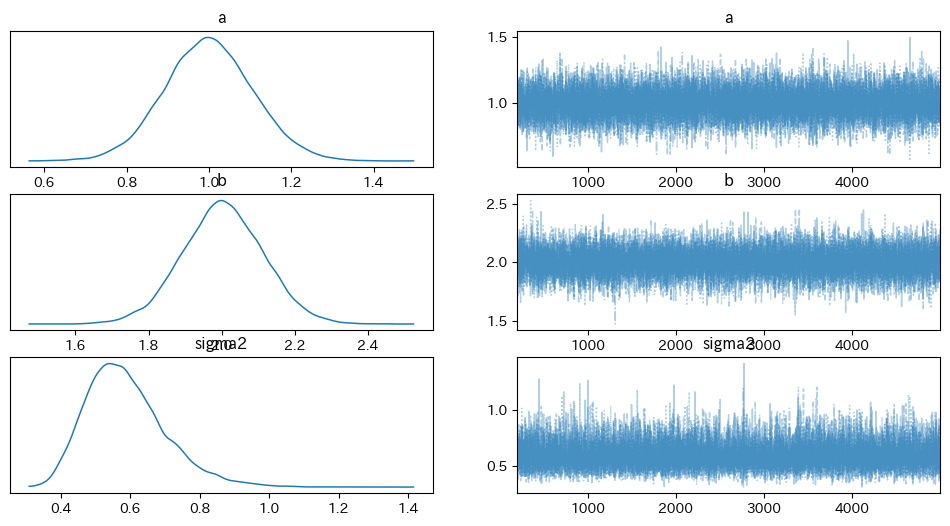

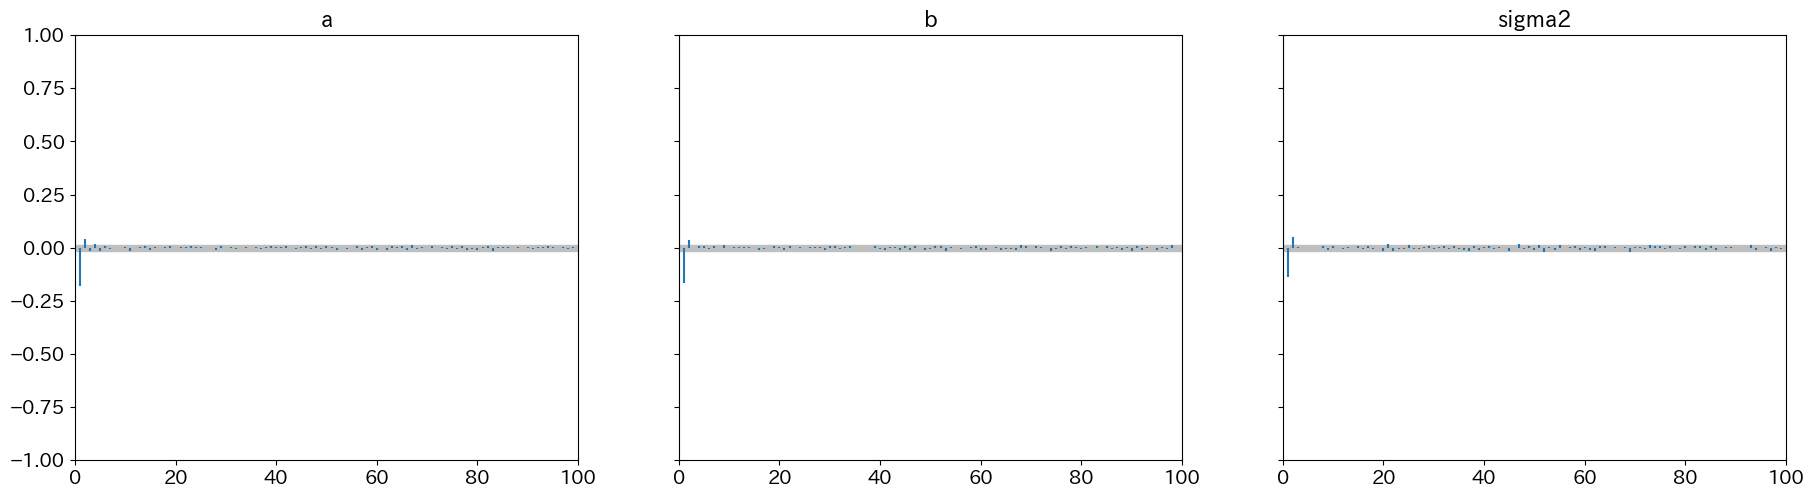

In [55]:
az.plot_trace(trace, combined=True) # 事後分布の可視化
az.plot_autocorr(trace, combined=True) # サンプリング時の自己相関
az.summary(trace) # 事後統計量

In [56]:
# xarray.DataArrayの使い方
print(trace.posterior['a'].values) # xr.DataArray -> np.ndarray
print(trace.posterior['a'].values.shape)
a_flat = trace.posterior['a'].values.flatten()
print(a_flat.shape)

[[1.04039846 0.96727964 0.90109089 ... 1.01689884 1.00670818 0.99573089]
 [1.03491396 0.83439852 0.83439852 ... 1.13449925 0.98317981 1.0508314 ]
 [0.98482034 0.93318679 1.08945095 ... 1.04267965 0.90681193 1.1048357 ]
 [0.89115297 1.08241227 0.93350582 ... 1.02344448 0.91383101 1.1020127 ]]
(4, 4800)
(19200,)


旧来のやり方

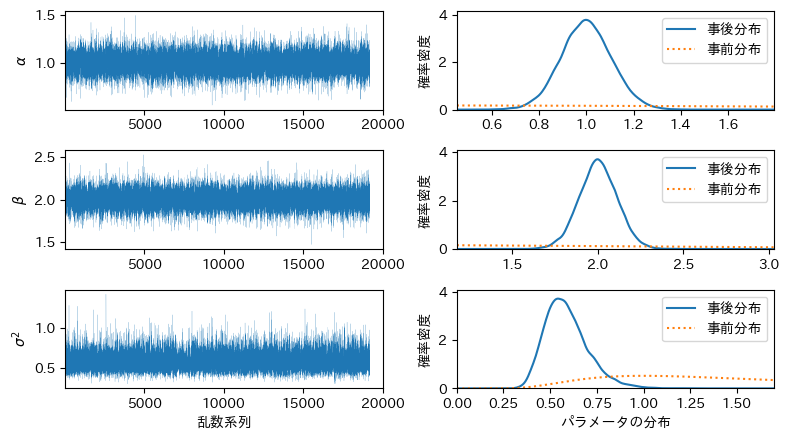

In [57]:
# 事後分布の作成
k = b0.size
param_names = ['a', 'b', 'sigma2']
labels = ['$\\alpha$', '$\\beta$', '$\\sigma^2$']
fig, ax = plt.subplots(k+1, 2, num=1, figsize=(8, 1.5 * (k+1)))
for index in range(k+1):
    # xr.DataArray -> np.ndarray -> (4, 5000) -> (20000,)
    posterior_trace = trace.posterior[param_names[index]].values.flatten() 
    
    # 回帰係数
    if index < k:
        x_min = posterior_trace.min() - 0.2 * np.abs(posterior_trace.min())
        x_max = posterior_trace.max() + 0.2 * np.abs(posterior_trace.max())
        x = np.linspace(x_min, x_max, 250)
        prior = st.norm.pdf(x, loc=b0[index], scale=sd0[index])
    else:
        x_min = 0.0
        x_max = posterior_trace.max() + 0.2 * np.abs(posterior_trace.max())
        x = np.linspace(x_min, x_max, 250)
        prior = st.invgamma.pdf(x, 0.5*nu0, scale=0.5*lam0)
        ax[index, 0].set_xlabel('乱数系列')
        ax[index, 1].set_xlabel('パラメータの分布')
    
    ax[index, 0].plot(posterior_trace, '-', linewidth=0.1)
    ax[index, 0].set_xlim(1, n_draws*n_chains)
    ax[index, 0].set_ylabel(labels[index])
    posterior = st.gaussian_kde(posterior_trace).evaluate(x)
    ax[index, 1].plot(x, posterior, '-', label='事後分布')
    ax[index, 1].plot(x, prior, ':', label='事前分布')
    ax[index, 1].set_xlim(x_min, x_max)
    ax[index, 1].set_ylim(0, 1.1*posterior.max())
    ax[index, 1].set_ylabel('確率密度')
    ax[index, 1].legend(loc='best')

plt.tight_layout()
plt.savefig('pybayes_fig_mcmc_reg_ex1.png', dpi=300)
plt.show()


### 実行標本数の意味と活用
+ 標本(モンテカルロ標本)平均
$$ \bar{\theta} = \frac{1}{T}\sum^{T}_{t=1}\theta_i$$
+ ラグS
$$ \hat{\gamma_s} = \frac{1}{T}\sum^{T}_{t=s+1}(\theta_t - \bar{\theta})(\theta_{t-s} - \bar{\theta}) $$
+ 標本自己相関
$$ \hat{\rho_s} = \frac{\hat{\gamma_s}}{\hat{\gamma_0}} $$
+ 実行標本数
$$ \hat{T_e} = \frac{T}{1 + 2 \sum^{S}_{s=1}\hat{\rho_s}} $$
+ モンテカルロ標本が自己相関を持つ場合の標本平均$\bar{\theta}$の近似誤差
$$ SE_{S}[\bar{\theta}] = \sqrt{\frac{1}{T}(\hat{\gamma_0}+2\sum^{S}_{s=1}\hat{\gamma_s})} = \sqrt{\frac{\hat{\gamma_0}}{T}(1+2\sum^{S}_{s=1}\hat{\rho_s})} $$
+ Tが十分大きい場合, $\hat{\gamma_0}$ は, 標本分散 $ \frac{1}{T(T-1)}\sum^{T}_{t=1}(\theta_t - \hat{\theta})^2 $ に等しいので
$$ SE_{S}[\bar{\theta}] = \sqrt{\frac{\frac{1}{T(T-1)}\sum^{T}_{t=1}(\theta_t - \hat{\theta})^2}{T}(1+2\sum^{S}_{s=1}\hat{\rho_s})} = \sqrt{\frac{\frac{1}{T(T-1)}\sum^{T}_{t=1}(\theta_t - \hat{\theta})^2}{T}\frac{T}{\hat{T_e}}} = \sqrt{\frac{1}{T}} SE[\bar{\theta}] \sqrt{\frac{T}{\hat{T_e}}}$$

### Gelman-Rubinの収束判定

回帰モデルのベイズ分析(正規分布+逆ガンマ分布)

In [3]:
# 回帰モデルからの人工データの生成
n = 50
np.random.seed(99)

# 誤差項 u
u = st.norm.rvs(scale=0.7, size=n)

# 説明変数
x = st.uniform.rvs(loc=-np.sqrt(3.0), scale=2.0*np.sqrt(3.0), size=n)

# 被説明変数
y = 1.0 + 2.0 * x + u

In [5]:
# 回帰モデルの係数と誤差項の事前分布
b0 = np.zeros(2) # 係数
A0 = 0.2 * np.eye(2) # 精度行列
nu0 = 5.0 # 自由度
lam0 = 7.0 # 尺度
# h0 = np.sqrt(np.diag(lam0 / nu0 * la.inv(A0)))
sd0 = np.sqrt(np.diag(la.inv(A0)))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma2, a, b]


/home/inoue/miniconda3/envs/Py312Env/lib/python3.12/site-packages/rich/live.py:231: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 6 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,1.001,0.106,0.802,1.202,0.001,0.000,28432.0,15317.0,1.0
b,2.007,0.111,1.803,2.221,0.001,0.000,25583.0,15177.0,1.0
sigma2,0.590,0.120,0.384,0.811,0.001,0.001,25179.0,14492.0,1.0


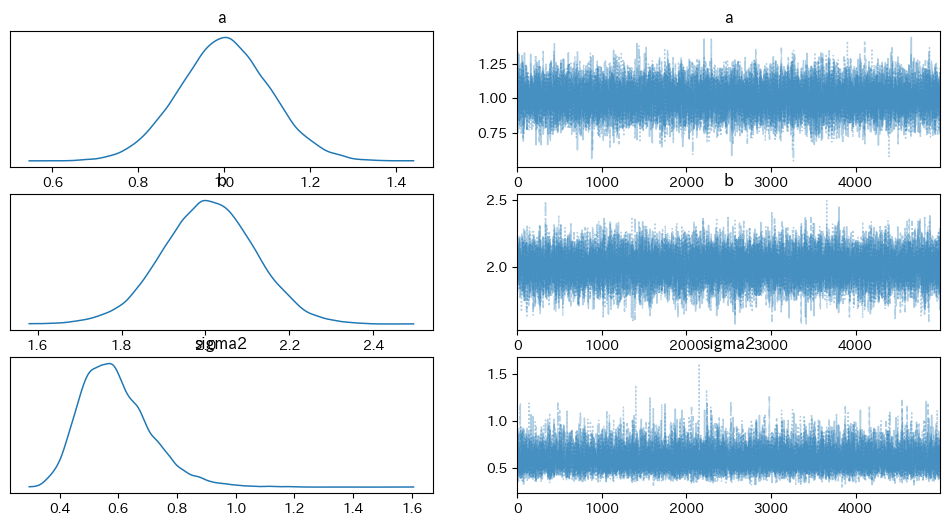

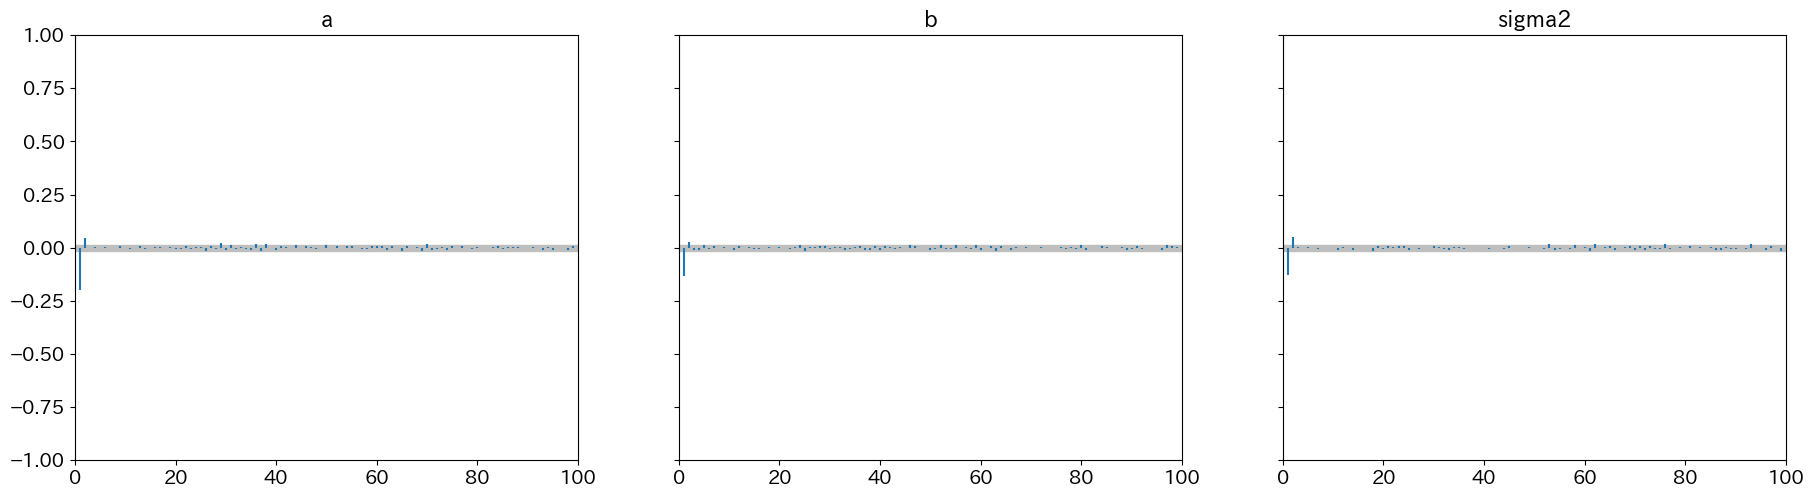

In [7]:
# 事前分布と尤度の設定
regression_normal_invgamma = pm.Model()
with regression_normal_invgamma:
    # 分散の事前分布
    sigma2 = pm.InverseGamma('sigma2', alpha=0.5*nu0, beta=0.5*lam0)
    # sigma = pm.math.sqrt(sigma2)


    # 回帰係数の事前分布
    # a = pm.Normal('a', mu=b0[0], sigma=sigma*sd0[0]) # 定数項
    # b = pm.Normal('b', mu=b0[1], sigma=sigma*sd0[1]) # 説明変数x_1
    a = pm.Normal('a', mu=b0[0], sigma=sd0[0])
    b = pm.Normal('b', mu=b0[1], sigma=sd0[1])

    # 回帰モデルの条件付き期待値
    y_hat = a + b * x

    # 尤度
    # likelihood = pm.Normal('y', mu=y_hat, sigma=sigma, observed=y)
    likelihood = pm.Normal('y', mu=y_hat, sigma=pm.math.sqrt(sigma2), observed=y)


# 事後分布からのサンプリング
n_draws = 5000
n_chains = 4
n_tune = 1000
with regression_normal_invgamma:
    trace = pm.sample(draws=n_draws, chains=n_chains, tune=n_tune, random_seed=1234)

# print(pm.summary(trace))

az.plot_trace(trace, combined=True) # 事後分布の可視化
az.plot_autocorr(trace, combined=True) # サンプリング時の自己相関
az.summary(trace) # 事後統計量

回帰モデルのベイズ分析(重回帰モデル)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma2, b]


/home/inoue/miniconda3/envs/Py312Env/lib/python3.12/site-packages/rich/live.py:231: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 5 seconds.


         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
b[0]    0.975  0.110   0.769    1.185      0.001    0.001   20943.0   15774.0   
b[1]    2.023  0.112   1.812    2.231      0.001    0.000   27637.0   15886.0   
b[2]   -0.868  0.112  -1.070   -0.647      0.001    0.001   20112.0   15358.0   
sigma2  0.586  0.120   0.381    0.812      0.001    0.001   25360.0   15697.0   

        r_hat  
b[0]      1.0  
b[1]      1.0  
b[2]      1.0  
sigma2    1.0  
<xarray.DataArray 'b' (chain: 4, draw: 5000, b_dim_0: 3)> Size: 480kB
array([[[ 1.04138622,  2.130472  , -0.8731201 ],
        [ 1.11160906,  2.04866613, -0.95870567],
        [ 0.78766156,  1.9995716 , -0.84760182],
        ...,
        [ 0.96744836,  2.06194296, -0.9642468 ],
        [ 0.96744836,  2.06194296, -0.9642468 ],
        [ 0.82698117,  2.04405912, -0.90497175]],

       [[ 0.96095707,  2.03182102, -0.87512826],
        [ 1.01230978,  2.01294926, -0.87456166],
        [ 0.9334456 ,  2.06921154, -0

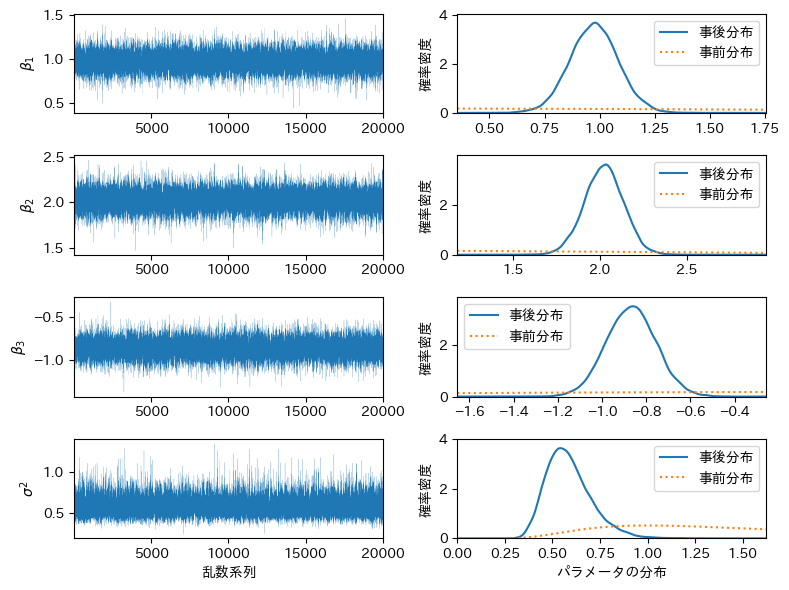

In [13]:
# 回帰モデルからデータを生成
import random


n = 50
np.random.seed(99)
u = st.norm.rvs(scale=0.7, size=n)
x1 = st.uniform.rvs(loc=-np.sqrt(3.0), scale=2.0 * np.sqrt(3.0), size=n)
x2 = st.uniform.rvs(loc=-np.sqrt(3.0), scale=2.0 * np.sqrt(3.0), size=n)
y = 1.0 + 2.0 * x1 - x2 + u
X = np.stack((np.ones(n), x1, x2), axis=1)

# 回帰モデルの係数と誤差項のぶんさんの事後分布設定
k = X.shape[1]
b0 = np.zeros(k)
A0 = 0.2 * np.eye(k)
nu0 = 5.0
lam0 = 7.0
sd0 = np.sqrt(np.diag(la.inv(A0)))
multiple_regression = pm.Model()
with multiple_regression:
    sigma2 = pm.InverseGamma('sigma2', alpha=0.5*nu0, beta=0.5*lam0)
    b = pm.MvNormal('b', mu=b0, tau=A0, shape=k)
    y_hat = pm.math.dot(X, b)
    likelihood = pm.Normal('y', mu=y_hat, sigma=pm.math.sqrt(sigma2), observed=y)

# 事後分布からのサンプリング
n_draws = 5000
n_chains = 4
n_tune = 1000
with multiple_regression:
    trace = pm.sample(draws=n_draws, chains=n_chains, tune=n_tune, random_seed=123)

print(pm.summary(trace))
print(trace.posterior['b'])

# 事後分布の作図
fig, ax = plt.subplots(k+1, 2, num=1, figsize=(8, 1.5*(k+1)))
for index in range(k+1):
    if index < k:
        mc_trace = trace.posterior['b'][..., index].values.flatten()  # b0, b1, b2
        x_min = mc_trace.min() - 0.2 * np.abs(mc_trace.min())
        x_max = mc_trace.max() + 0.2 * np.abs(mc_trace.max())
        x = np.linspace(x_min, x_max, 250)
        prior = st.norm.pdf(x, loc=b0[index], scale=sd0[index])
        y_label = f"$\\beta_{index+1:<d}$"
    else:
        mc_trace = trace.posterior['sigma2'].values.flatten()
        x_min = 0
        x_max = mc_trace.max() + 0.2 * np.abs(mc_trace.max())
        x = np.linspace(x_min, x_max, 250)
        prior = st.invgamma.pdf(x, 0.5*nu0, scale=0.5*lam0)
        y_label = f"$\\sigma^2$"
        ax[index, 0].set_xlabel("乱数系列")
        ax[index, 1].set_xlabel("パラメータの分布")
    
    ax[index, 0].plot(mc_trace, '-', linewidth=0.1)
    ax[index, 0].set_xlim(1, n_draws*n_chains)
    ax[index, 0].set_ylabel(y_label)
    posterior = st.gaussian_kde(mc_trace).evaluate(x)
    ax[index, 1].plot(x, posterior, '-', label='事後分布')
    ax[index, 1].plot(x, prior, ':', label='事前分布')
    ax[index, 1].set_xlim(x_min, x_max)
    ax[index, 1].set_ylim(0, 1.1 * posterior.max())
    ax[index, 1].set_ylabel('確率密度')
    ax[index, 1].legend()

plt.tight_layout()
plt.show()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b[0],0.975,0.110,0.769,1.185,0.001,0.001,20943.0,15774.0,1.0
b[1],2.023,0.112,1.812,2.231,0.001,0.000,27637.0,15886.0,1.0
b[2],-0.868,0.112,-1.070,-0.647,0.001,0.001,20112.0,15358.0,1.0
sigma2,0.586,0.120,0.381,0.812,0.001,0.001,25360.0,15697.0,1.0


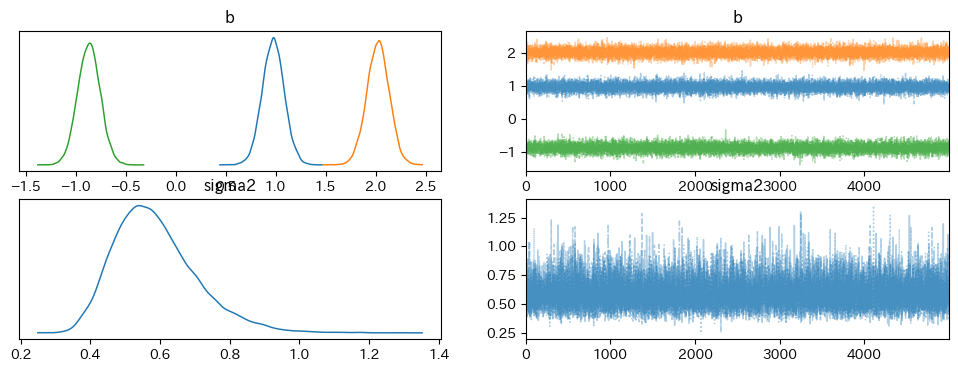

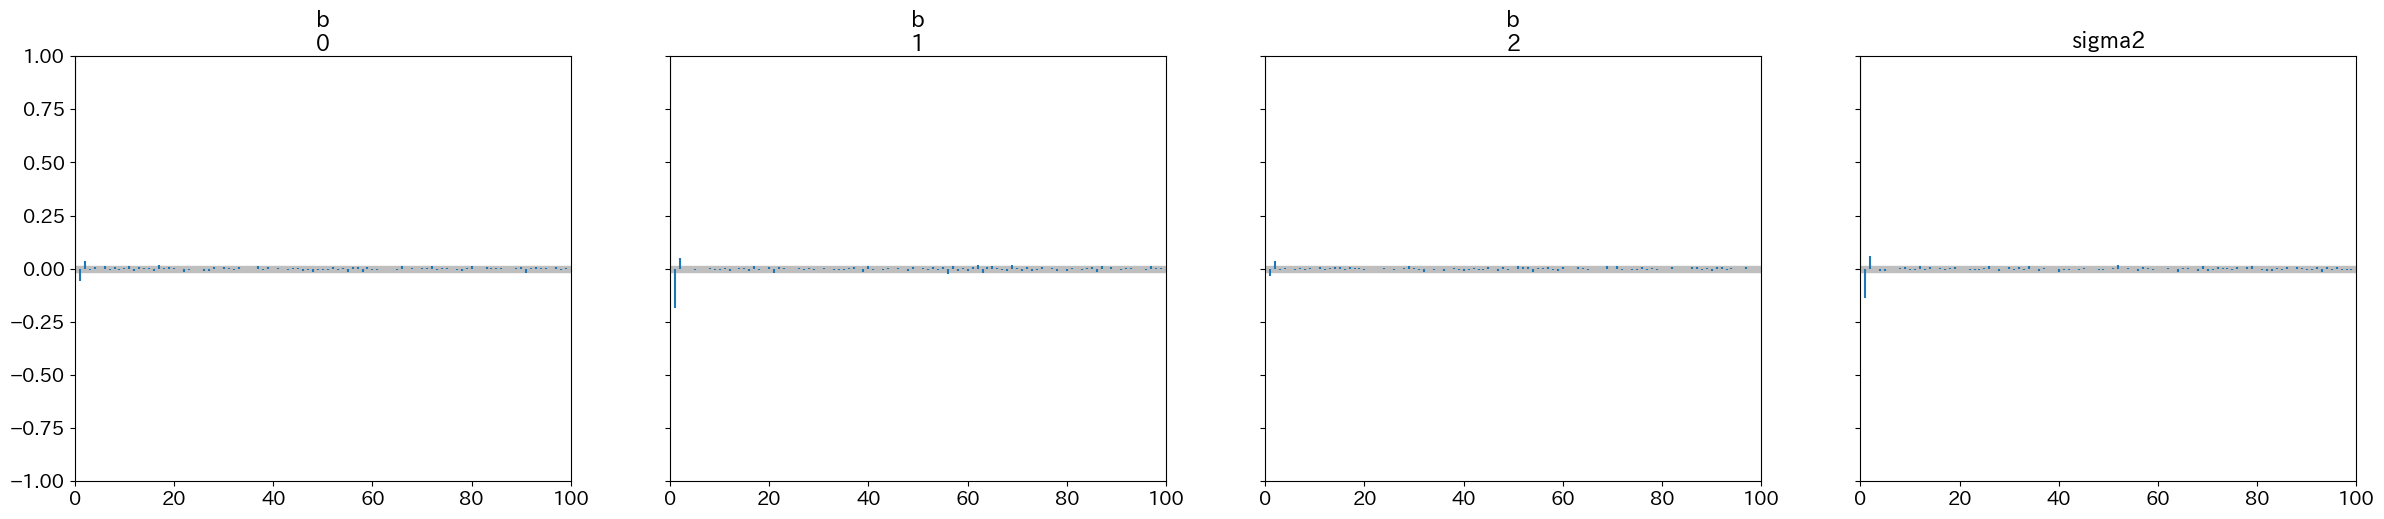

In [14]:
az.plot_trace(trace, combined=True) # 事後分布の可視化
az.plot_autocorr(trace, combined=True) # サンプリング時の自己相関
az.summary(trace) # 事後統計量

回帰モデルのベイズ分析(ラプラス分布+半コーシー分布)
+ ラプラス分布(実直線上の値をすべて取る)
$$ La(\mu,\sigma) = p(x|\mu,\sigma) = \frac{1}{2\sigma}exp[-\frac{|x-\mu|}{\sigma}] $$
+ コーシー分布(自由度1のt分布)
$$ Ca(\mu,\sigma) = p(x|\mu,\sigma) = \frac{1}{\pi\sigma}[1+(\frac{x-\mu}{\sigma})^2]^{-1} $$
+ 半コーシー分布(コーシー分布のx>0 p(x)=1) ※切断したもの
$$ Ca^{+}(\sigma) = p(x|\sigma) = \frac{2}{\pi\sigma}(1+\frac{x^2}{\sigma^2})^{-1} = \frac{2\sigma}{\pi(x^2+\sigma^2)}, x > 0 $$

In [18]:
# 回帰モデルからデータを生成
import random


n = 50
np.random.seed(99)
u = st.norm.rvs(scale=0.7, size=n)
# x1 = st.uniform.rvs(loc=-np.sqrt(3.0), scale=2.0 * np.sqrt(3.0), size=n)
# x2 = st.uniform.rvs(loc=-np.sqrt(3.0), scale=2.0 * np.sqrt(3.0), size=n)
# y = 1.0 + 2.0 * x1 - x2 + u
# X = np.stack((np.ones(n), x1, x2), axis=1)
x = st.uniform.rvs(loc=-np.sqrt(3.0), scale=2.0 * np.sqrt(3.0), size=n)
y = 1.0 + 2.0 * x + u

# 回帰モデルの係数と誤差項のぶんさんの事後分布設定
# k = X.shape[1]
# b0 = np.zeros(k)
# A0 = 0.2 * np.eye(k)
# nu0 = 5.0
# lam0 = 7.0
# sd0 = np.sqrt(np.diag(la.inv(A0)))
# multiple_regression = pm.Model()
# with multiple_regression:
    # sigma2 = pm.InverseGamma('sigma2', alpha=0.5*nu0, beta=0.5*lam0)
    # b = pm.MvNormal('b', mu=b0, tau=A0, shape=k)
    # y_hat = pm.math.dot(X, b)
    # likelihood = pm.Normal('y', mu=y_hat, sigma=pm.math.sqrt(sigma2), observed=y)

b0 = np.zeros(2)
tau_coef = np.ones(2)
tau_sigma = 1.0
regression_laplace_halfcauchy = pm.Model()
with regression_laplace_halfcauchy:
    sigma = pm.HalfCauchy('sigma', beta=tau_sigma)
    a = pm.Laplace('a', mu=b0[0], b=tau_coef[0])
    b = pm.Laplace('b', mu=b0[1], b=tau_coef[1])
    y_hat = a + b * x
    likelihood = pm.Normal('y', mu=y_hat, sigma=sigma, observed=y)

# 事後分布からのサンプリング
n_draws = 5000
n_chains = 4
n_tune = 1000
with regression_laplace_halfcauchy:
    trace = pm.sample(draws=n_draws, chains=n_chains, tune=n_tune, random_seed=123)

# az.plot_trace(trace, combined=True) # 事後分布の可視化
# az.plot_autocorr(trace, combined=True) # サンプリング時の自己相関
# az.summary(trace) # 事後統計量


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, a, b]


/home/inoue/miniconda3/envs/Py312Env/lib/python3.12/site-packages/rich/live.py:231: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 3 seconds.


        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
a      0.993  0.101   0.800    1.182      0.001      0.0   25764.0   15106.0   
b      2.001  0.104   1.804    2.197      0.001      0.0   25336.0   15140.0   
sigma  0.707  0.073   0.578    0.845      0.000      0.0   24574.0   14683.0   

       r_hat  
a        1.0  
b        1.0  
sigma    1.0  


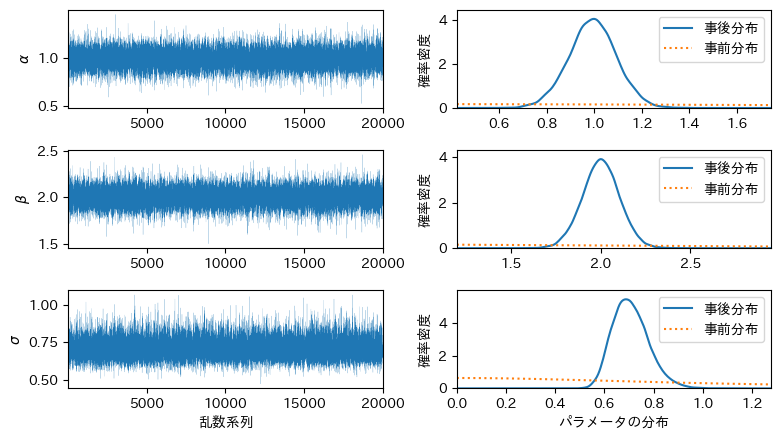

In [19]:
print(pm.summary(trace))

# 事後分布の作成
k = b0.size
param_names = ['a', 'b', 'sigma']
labels = ['$\\alpha$', '$\\beta$', '$\\sigma$']
fig, ax = plt.subplots(k+1, 2, num=1, figsize=(8, 1.5 * (k+1)))
for index in range(k+1):
    # xr.DataArray -> np.ndarray -> (4, 5000) -> (20000,)
    posterior_trace = trace.posterior[param_names[index]].values.flatten() 
    
    # 回帰係数
    if index < k:
        x_min = posterior_trace.min() - 0.2 * np.abs(posterior_trace.min())
        x_max = posterior_trace.max() + 0.2 * np.abs(posterior_trace.max())
        x = np.linspace(x_min, x_max, 250)
        prior = st.norm.pdf(x, loc=b0[index], scale=sd0[index])
    else:
        x_min = 0.0
        x_max = posterior_trace.max() + 0.2 * np.abs(posterior_trace.max())
        x = np.linspace(x_min, x_max, 250)
        prior = st.halfcauchy.pdf(x, scale=tau_sigma)
        ax[index, 0].set_xlabel('乱数系列')
        ax[index, 1].set_xlabel('パラメータの分布')
    
    ax[index, 0].plot(posterior_trace, '-', linewidth=0.1)
    ax[index, 0].set_xlim(1, n_draws*n_chains)
    ax[index, 0].set_ylabel(labels[index])
    posterior = st.gaussian_kde(posterior_trace).evaluate(x)
    ax[index, 1].plot(x, posterior, '-', label='事後分布')
    ax[index, 1].plot(x, prior, ':', label='事前分布')
    ax[index, 1].set_xlim(x_min, x_max)
    ax[index, 1].set_ylim(0, 1.1*posterior.max())
    ax[index, 1].set_ylabel('確率密度')
    ax[index, 1].legend(loc='best')

plt.tight_layout()
# plt.savefig('pybayes_fig_mcmc_reg_ex1.png', dpi=300)
plt.show()